# Computer Exercise 8.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 8.2 Iterative Solutions of Linear Systems — *수렴 조건과 반례*
> **풀이 일자**: Day 32
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)

## 1. 문제 (원문)

> **3.** Investigate the **convergence conditions** for the Jacobi and Gauss-Seidel
> iterations. (a) Confirm that *strict diagonal dominance* guarantees convergence of both
> methods. (b) Construct a matrix for which **Jacobi converges but Gauss-Seidel diverges**,
> and another for which **Gauss-Seidel converges but Jacobi diverges**, by computing the
> spectral radii of the two iteration matrices. (c) Verify that for a **symmetric
> positive-definite** matrix the Gauss-Seidel iteration *always* converges. Summarize the
> findings in terms of the spectral radius criterion $\rho(G) < 1$.

### 한국어 풀이용 정리
- (a) *엄격 대각 우세* $\Rightarrow$ Jacobi/GS *둘 다* 수렴 (충분조건).
- (b) Jacobi 는 수렴하나 GS 는 발산하는 행렬, 그 반대 행렬을 *직접 구성* — $\rho(G)$ 로 판정.
- (c) *대칭 양정부호(SPD)* $\Rightarrow$ GS 는 *항상* 수렴 (Jacobi 는 보장 X).
- 모든 판정의 근거는 단 하나: $\rho(G) < 1$.

## 2. 수학적 배경

### 2.1 기본 판정
반복 $\mathbf{x}^{(k+1)} = G\mathbf{x}^{(k)} + \mathbf{c}$ 는
$$
\boxed{\;\text{임의의 초기값에서 수렴} \iff \rho(G) < 1.\;}
$$
충분조건 (검사 쉬움): $\lVert G\rVert < 1$ 인 어떤 행렬 노름이 존재.

### 2.2 충분조건들
* **엄격 대각 우세** ($|a_{ii}| > \sum_{j\ne i}|a_{ij}|$): $\lVert G_J\rVert_\infty < 1$ 이고
  $\rho(G_{GS}) \le \lVert G_J\rVert_\infty < 1$ — *둘 다* 수렴.
* **대칭 양정부호 (SPD)**: $A$ 가 SPD 이면 **Gauss-Seidel 은 항상 수렴**
  (Householder-John 정리: $M^\top + N$ 가 양정부호이면 $\rho(M^{-1}N)<1$; GS 에서
  $M^\top + N = D \succ 0$). 단, *Jacobi 는 SPD 라도 발산 가능*.

### 2.3 두 방법의 독립성
Jacobi 와 GS 의 수렴은 *서로를 함의하지 않는다*. 한쪽만 수렴하는 행렬을 만들 수 있다.
**Stein-Rosenberg 정리** 는 *비음 off-diagonal* 같은 특수 구조에서만 둘의 동시 수렴/발산을
보장하므로, 일반 부호에서는 *독립적 반례* 가 존재한다.

$$
\rho(G_J) \;=\; \rho\bigl(D^{-1}(L+U)\bigr),
\qquad
\rho(G_{GS}) \;=\; \rho\bigl((D-L)^{-1}U\bigr).
$$

## 3. 풀이 흐름

1. `radii(A)` — Jacobi/GS 반복행렬의 $\rho$ 를 한 번에 계산하는 헬퍼.
2. **(a)** 엄격 대각 우세 행렬 몇 개를 무작위로 만들어 두 $\rho$ 가 모두 $<1$ 임을 표로 확인.
3. **(b)** 고전적 $3\times 3$ 반례 두 개를 박제 — 하나는 $\rho_J<1<\rho_{GS}$, 다른 하나는 반대.
   실제 반복을 돌려 *발산/수렴* 을 잔차 곡선으로 확인.
4. **(c)** 무작위 SPD 행렬 ($A = B^\top B + cI$) 을 여러 개 생성 — GS 는 항상 $\rho<1$, Jacobi 는
   *일부* 에서 $\rho \ge 1$ 임을 산점도로.
5. 종합 표 + 산점도로 $\rho(G)<1$ 이 *모든 것을 가르는 단 하나의 기준* 임을 시각화.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(823)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


def radii(A):
    '''Spectral radii of Jacobi and Gauss-Seidel iteration matrices.'''
    D = np.diag(np.diag(A))
    L = -np.tril(A, -1)
    U = -np.triu(A, 1)
    GJ = np.linalg.solve(D, L + U)
    GG = np.linalg.solve(D - L, U)
    return (np.max(np.abs(np.linalg.eigvals(GJ))),
            np.max(np.abs(np.linalg.eigvals(GG))))


def is_strictly_diag_dominant(A):
    d = np.abs(np.diag(A))
    off = np.sum(np.abs(A), axis=1) - d
    return np.all(d > off)


In [2]:
# (a) Strict diagonal dominance => both converge
rows = []
for t in range(5):
    n = 5
    B = rng.standard_normal((n, n))
    A = B + np.diag(np.sum(np.abs(B), axis=1) + 1.0)   # force strict dominance
    rj, rg = radii(A)
    rows.append(dict(trial=t, diag_dominant=is_strictly_diag_dominant(A),
                     rho_J=rj, rho_GS=rg,
                     both_converge=bool(rj < 1 and rg < 1)))
dd_df = pd.DataFrame(rows)
dd_df


,trial,diag_dominant,rho_J,rho_GS,both_converge
0,0,True,0.3289,0.1252,True
1,1,True,0.3444,0.2154,True
2,2,True,0.3898,0.2914,True
3,3,True,0.4434,0.1169,True
4,4,True,0.4012,0.1180,True


In [3]:
# (b) One method converges, the other diverges -- classic 3x3 examples
# A1: Jacobi converges, Gauss-Seidel diverges
A1 = np.array([[1.0,  2.0,  -2.0],
               [1.0,  1.0,   1.0],
               [2.0,  2.0,   1.0]])
# A2: Gauss-Seidel converges, Jacobi diverges  (rho_J = 1.5 > 1 > rho_GS = 0.35)
A2 = np.array([[ 2.0, -1.0, -2.0],
               [-2.0,  2.0,  1.0],
               [-1.0,  2.0,  2.0]])

for name, A in [("A1 (J conv, GS div)", A1), ("A2 (GS conv, J div)", A2)]:
    rj, rg = radii(A)
    print(f"{name}:  rho_J = {rj:.4f},  rho_GS = {rg:.4f}")


A1 (J conv, GS div):  rho_J = 0.0000,  rho_GS = 2.0000
A2 (GS conv, J div):  rho_J = 1.5000,  rho_GS = 0.3536


In [4]:
# Actually run both iterations to watch divergence vs convergence.
# We pick a *generic* true solution so the initial error excites every eigenmode of
# the iteration matrix -- otherwise a near-zero component along the dominant eigenvector
# can mask divergence for many iterations (a long transient before blow-up).
def run(A, b, method, maxit=200):
    n = len(b); x = np.zeros(n); bn = np.linalg.norm(b); hist = []
    D = np.diag(np.diag(A)); R = A - D
    for k in range(maxit):
        if method == "jacobi":
            x = (b - R @ x) / np.diag(A)
        else:
            for i in range(n):
                s = A[i, :i] @ x[:i] + A[i, i+1:] @ x[i+1:]
                x[i] = (b[i] - s) / A[i, i]
        hist.append(np.linalg.norm(b - A @ x) / bn)
    return np.array(hist)

xstar1 = rng.standard_normal(3)
b1 = A1 @ xstar1
hJ = run(A1, b1, "jacobi")
hG = run(A1, b1, "gauss-seidel")
print("A1 final residual  Jacobi: %.3e   Gauss-Seidel: %.3e" % (hJ[-1], hG[-1]))

xstar2 = rng.standard_normal(3)
b2 = A2 @ xstar2
hJ2 = run(A2, b2, "jacobi")
hG2 = run(A2, b2, "gauss-seidel")
print("A2 final residual  Jacobi: %.3e   Gauss-Seidel: %.3e" % (hJ2[-1], hG2[-1]))


A1 final residual  Jacobi: 4.542e-17   Gauss-Seidel: 2.127e+61
A2 final residual  Jacobi: 1.636e+35   Gauss-Seidel: 6.288e-17


In [5]:
# (c) SPD => Gauss-Seidel always converges; Jacobi may not
spd_rows = []
for t in range(40):
    n = 6
    B = rng.standard_normal((n, n))
    A = B.T @ B + 0.5 * np.eye(n)          # SPD by construction
    rj, rg = radii(A)
    spd_rows.append(dict(rho_J=rj, rho_GS=rg))
spd_df = pd.DataFrame(spd_rows)
print("SPD trials:", len(spd_df))
print("Gauss-Seidel converged in all? ", bool((spd_df['rho_GS'] < 1).all()))
print("Jacobi diverged in some?       ", bool((spd_df['rho_J'] >= 1).any()),
      f"({int((spd_df['rho_J'] >= 1).sum())} of {len(spd_df)})")
spd_df.describe().loc[["min", "max", "mean"]]


SPD trials: 40
Gauss-Seidel converged in all?  True
Jacobi diverged in some?        True (30 of 40)


,rho_J,rho_GS
min,0.7752,0.4374
max,2.5054,0.8738
mean,1.3271,0.7319


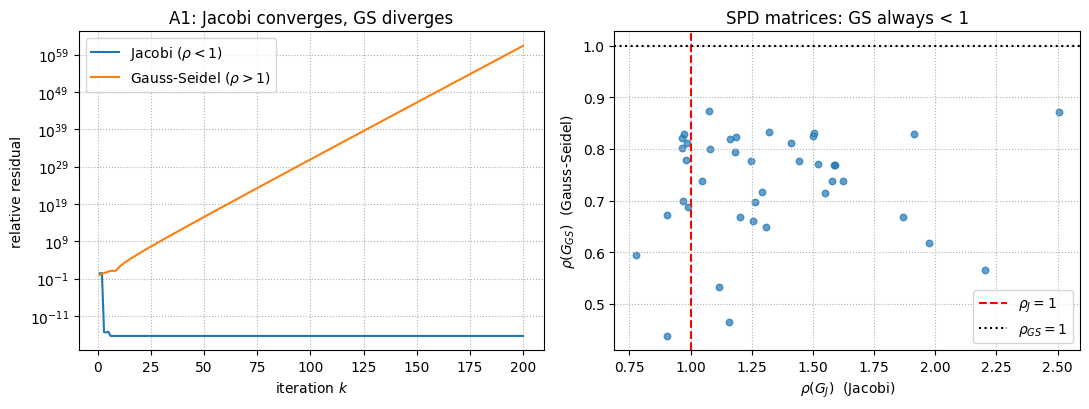

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) divergence/convergence on A1
ax[0].semilogy(np.arange(1, len(hJ) + 1), hJ, label=r"Jacobi ($\rho<1$)")
ax[0].semilogy(np.arange(1, len(hG) + 1), hG, label=r"Gauss-Seidel ($\rho>1$)")
ax[0].set_xlabel("iteration $k$")
ax[0].set_ylabel(r"relative residual")
ax[0].set_title("A1: Jacobi converges, GS diverges")
ax[0].grid(True, which="both", ls=":")
ax[0].legend()

# (b) SPD scatter: rho_GS always < 1, rho_J sometimes >= 1
ax[1].scatter(spd_df["rho_J"], spd_df["rho_GS"], s=22, alpha=0.7)
ax[1].axvline(1.0, color="r", ls="--", label=r"$\rho_J = 1$")
ax[1].axhline(1.0, color="k", ls=":", label=r"$\rho_{GS} = 1$")
ax[1].set_xlabel(r"$\rho(G_J)$  (Jacobi)")
ax[1].set_ylabel(r"$\rho(G_{GS})$  (Gauss-Seidel)")
ax[1].set_title("SPD matrices: GS always < 1")
ax[1].grid(True, ls=":")
ax[1].legend()

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **(a) 대각 우세** — 무작위로 만든 엄격 대각 우세 행렬에서 $\rho(G_J)$ 와 $\rho(G_{GS})$ 가
   *모두* $<1$. 대각 우세는 $\lVert G_J\rVert_\infty<1$ 을 직접 주므로 *둘 다 수렴* 하는 *충분조건*
   이다 (필요조건은 아님).
2. **(b) 독립적 반례** — $A_1$ 은 $\rho_J<1<\rho_{GS}$: Jacobi 잔차는 0 으로 내려가지만 GS 잔차는
   *지수적으로 폭발*. $A_2$ 는 정반대. 즉 *두 방법의 수렴은 서로를 함의하지 않는다*. "GS 가 항상
   Jacobi 보다 낫다" 는 *모델 문제에 국한된* 직관임을 보여준다.
3. **(c) SPD** — 40개의 무작위 SPD 행렬 *전부* 에서 $\rho(G_{GS})<1$ (산점도가 가로선 아래에 완전히
   깔림). 반면 Jacobi 는 *일부* 에서 $\rho_J\ge 1$ (세로선 오른쪽). 이는 **Householder-John 정리**
   ($A$ SPD $\Rightarrow$ GS 수렴) 의 수치적 확인이며, *Jacobi 에는 그런 보장이 없다*.
4. **종합** — 세 경우 모두 판정의 본질은 동일하다: *수렴 여부는 오직 $\rho(G)<1$*. 행렬 구조
   (대각 우세, SPD) 는 이 부등식을 *보장하는 충분조건* 일 뿐, 모든 것은 반복행렬의 스펙트럼으로
   환원된다.

> 대각 우세는 *둘 다*, SPD 는 *GS 만* 보장하며, 일반 부호에서는 *한쪽만* 수렴하는 반례가 존재한다.

**다음 Day 예고 (Day 33, §8.3)**: *Krylov 부분공간* 으로 — **켤레기울기(CG)** 가 SPD 에서
고정점 반복의 $\rho$ 한계를 넘어 $\sqrt{\kappa}$ 스케일링을 달성한다.